In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

In [ ]:
# set drive/MyDrive/ ad base working directory
%cd /content/drive/MyDrive/dse-ml-2026/materials/2026-09-22_tuesday/05_jantscher_embeddings

In [ ]:
!pip install bertopic

# Dimensionality Reduction with PCA and UMAP

This notebook uses the ParlaMint utterance dataset to compare two ways of reducing Sentence Transformer embeddings.

We will:

- create one embedding vector for each grouped parliamentary utterance;
- reduce the vectors to two dimensions with PCA;
- reduce the same vectors to two dimensions with UMAP;
- compare the resulting layouts and inspect example utterances.

The two-dimensional outputs are useful for visualization. BERTopic may use more than two dimensions before clustering.

## 1. Setup and parameters

The main parameters to experiment with are:

- PCA: `n_components`
- UMAP: `n_neighbors`, `min_dist`, `n_components`, and `metric`

Start with the values below, then change one parameter at a time and observe how the layout changes.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from umap import UMAP

DATA_PATH = "../../datasets/parlamint/parlamint-it-is-2022.txt"
N_UTTERANCES = 100

embedding_model_name = "all-MiniLM-L6-v2"

In [4]:
# Load and group the ParlaMint data by utterance
df_parlamint = pd.read_csv(DATA_PATH, sep="\t").head(2000)

df_utterances = (
    df_parlamint.groupby("Parent_ID")["Text"]
    .apply(lambda sentences: " ".join(sentences))
    .reset_index(name="utterance_text")
    .head(N_UTTERANCES)
    .reset_index(drop=True)
)

print(f"Number of utterances: {len(df_utterances)}")
df_utterances[["Parent_ID", "utterance_text"]].head(3)

Number of utterances: 100


,Parent_ID,utterance_text
0,ParlaMint-IS_2022-01-17-20.u1,President of the United States reports: I have...
1,ParlaMint-IS_2022-01-17-20.u10,"Before the weekend, an article by Stefánssonar..."
2,ParlaMint-IS_2022-01-17-20.u11,"I read this decision in Perconte, which is not..."


In [5]:
# Create one Sentence Transformer embedding for each utterance
st_model = SentenceTransformer(embedding_model_name)

utterance_embeddings = st_model.encode(
    df_utterances["utterance_text"].tolist(),
    show_progress_bar=True,
)

print("Embedding matrix shape:", utterance_embeddings.shape)
# Expected shape: (number of utterances, embedding dimensions)

Batches: 100%|██████████| 4/4 [00:01<00:00,  2.65it/s]

Embedding matrix shape: (100, 384)


## 2. PCA

PCA finds linear directions that explain the largest amount of variation in the embedding matrix.

For this experiment, each point in the plot represents one parliamentary utterance. The two PCA coordinates are projections of the original embedding vector onto the first two principal components.

Explained variance per component: [0.10592031 0.06570735]
Total explained variance: 0.17162767


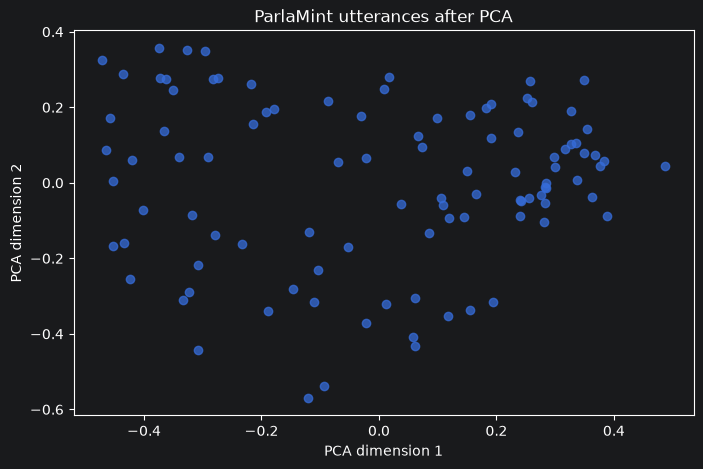

,Parent_ID,PCA_1,PCA_2
0,ParlaMint-IS_2022-01-17-20.u1,0.336594,0.008655
1,ParlaMint-IS_2022-01-17-20.u10,-0.334172,-0.309452
2,ParlaMint-IS_2022-01-17-20.u11,-0.323087,-0.288717
3,ParlaMint-IS_2022-01-17-20.u12,-0.119488,-0.130547
4,ParlaMint-IS_2022-01-17-20.u13,-0.307853,-0.218340


In [6]:
# PCA: reduce the utterance embeddings to two dimensions
pca_model = PCA(n_components=2)
pca_coordinates = pca_model.fit_transform(utterance_embeddings)

df_pca = df_utterances.copy()
df_pca[["PCA_1", "PCA_2"]] = pca_coordinates

print("Explained variance per component:", pca_model.explained_variance_ratio_)
print("Total explained variance:", pca_model.explained_variance_ratio_.sum())

plt.figure(figsize=(8, 5))
plt.scatter(pca_coordinates[:, 0], pca_coordinates[:, 1], alpha=0.75)
plt.xlabel("PCA dimension 1")
plt.ylabel("PCA dimension 2")
plt.title("ParlaMint utterances after PCA")
plt.show()

df_pca[["Parent_ID", "PCA_1", "PCA_2"]].head()

## 3. UMAP

UMAP first builds a weighted graph of local neighbors in the original embedding space. It then optimizes a lower-dimensional layout that preserves important neighborhood relationships.

Try changing `n_neighbors` and `min_dist` separately:

- smaller `n_neighbors`: more local structure;
- larger `n_neighbors`: broader structure;
- smaller `min_dist`: tighter groups;
- larger `min_dist`: more spread-out groups.

C:\Users\mjantscher\PycharmProjects\clariah_summer_school\dse-ml-2026\materials\2026-09-22_tuesday\05_jantscher_embeddings\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


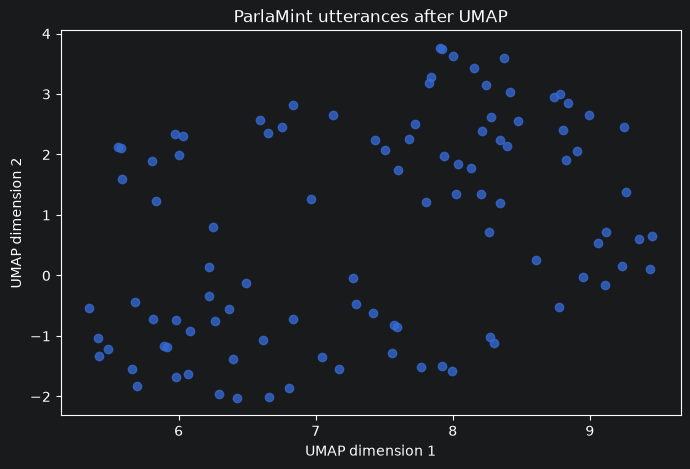

,Parent_ID,UMAP_1,UMAP_2
0,ParlaMint-IS_2022-01-17-20.u1,6.832469,2.813499
1,ParlaMint-IS_2022-01-17-20.u10,7.568032,-0.823745
2,ParlaMint-IS_2022-01-17-20.u11,7.416307,-0.626849
3,ParlaMint-IS_2022-01-17-20.u12,7.294333,-0.474097
4,ParlaMint-IS_2022-01-17-20.u13,7.595308,-0.844535


In [7]:
# UMAP: reduce the same utterance embeddings to two dimensions
umap_model = UMAP(
    n_neighbors=15,   # experiment with 5, 15, and 50
    n_components=2,
    min_dist=0.1,     # experiment with 0.0, 0.1, and 0.5
    metric="cosine",
    random_state=42,
)
umap_coordinates = umap_model.fit_transform(utterance_embeddings)

df_umap = df_utterances.copy()
df_umap[["UMAP_1", "UMAP_2"]] = umap_coordinates

plt.figure(figsize=(8, 5))
plt.scatter(umap_coordinates[:, 0], umap_coordinates[:, 1], alpha=0.75)
plt.xlabel("UMAP dimension 1")
plt.ylabel("UMAP dimension 2")
plt.title("ParlaMint utterances after UMAP")
plt.show()

df_umap[["Parent_ID", "UMAP_1", "UMAP_2"]].head()

## 4. Inspect the documents behind the points

The plots show coordinates, not topic labels. Inspect the text behind selected points to understand what the neighborhoods represent.

The helper below prints complete utterances rather than a truncated DataFrame view.

In [9]:
from sklearn.metrics import pairwise_distances

def show_closest_and_farthest(coordinates, coordinate_name):
    distances = pairwise_distances(coordinates, metric="euclidean")
    np.fill_diagonal(distances, np.inf)

    closest_pair = np.unravel_index(np.argmin(distances), distances.shape)

    distances_for_max = distances.copy()
    np.fill_diagonal(distances_for_max, -np.inf)
    farthest_pair = np.unravel_index(
        np.argmax(distances_for_max),
        distances_for_max.shape,
    )

    def print_pair(indices, title, pair_distances):
        print(f"\n{title}")
        print("=" * 100)
        print(f"Distance in the {coordinate_name} layout: {pair_distances[indices]:.4f}")

        for number, index in enumerate(indices, start=1):
            row = df_utterances.iloc[index]
            print(f"\nSample {number}: {row['Parent_ID']}")
            print("Full utterance:")
            print(row["utterance_text"])
            print("-" * 100)

    print_pair(
        closest_pair,
        f"Closest pair in the {coordinate_name} layout",
        distances,
    )
    print_pair(
        farthest_pair,
        f"Farthest pair in the {coordinate_name} layout",
        distances_for_max,
    )

show_closest_and_farthest(pca_coordinates, "PCA")
show_closest_and_farthest(umap_coordinates, "UMAP")


Closest pair in the PCA layout
Distance in the PCA layout: 0.0016

Sample 1: ParlaMint-IS_2022-01-17-20.u54
Full utterance:
This is the subject for a considerably longer answer than the minute I have here. As for when we're in a place where we're supposed to have fewer restrictions and that people can go to a restaurant if they choose to sit there for longer than 9 in the evening, it's certainly a major blow for this part of a job, and he's had to take a lot of action. But with support, we too have responded greatly. Of course, as soon as we get it all together, we want to get back to normal. About the first question why. The senator is the calculated amount of money that you personally give, so that the question is answered here in the Sermon on the Mount.
----------------------------------------------------------------------------------------------------

Sample 2: ParlaMint-IS_2022-01-17-20.u56
Full utterance:
If I understood why. A senator was just wondering if there was a need fo

## Exercises

1. Change `n_neighbors` and `min_dist` in UMAP. Which local groups become tighter or more dispersed?
2. Compare the closest pairs found by PCA and UMAP. Are the utterances about the same subject or only written in a similar parliamentary style?
3. Increase `n_components` to 5. How would the result differ from the two-dimensional visualization?
4. Try different numbers of utterances. Does the layout become more stable or more difficult to interpret?